In [6]:
from pathlib import Path
from data_paths import BIOEXP
import importlib
import phyto_sibciom

importlib.reload(phyto_sibciom)

from phyto_sibciom import inspect_nc, make_file_path, make_video, plot_snapshot
from data_paths import BIOEXP


In [7]:
EXP_NAME = 'noadv'  # 
DATA_DIR = BIOEXP  # model NetCDF directory

START_YEAR = 2011  # first year in the video 
START_MONTH = 1  
END_YEAR = 2017  # last year in the video 
END_MONTH = 9  

SNAP_YEAR = 2017  
SNAP_MONTH = 8  
VAR_NAME = 'phyto'  
PLOT_VMIN = None  #  None = auto
PLOT_VMAX = 1.5  # upper color limit

PLOT_CMAP = 'viridis'  # colormap; recommended: viridis, cividis, turbo, plasma

VIDEO_FPS = None  # None = derive from frame duration
FRAME_DURATION_SEC = 1.2  # seconds per frame when FPS is auto

OUT_DIR = Path('./pics') / EXP_NAME  # output directory
OUT_DIR.mkdir(parents=True, exist_ok=True)


In [8]:
test_file = make_file_path(DATA_DIR, SNAP_YEAR, SNAP_MONTH)
inspect_nc(test_file)


<class 'netCDF4.Dataset'>
root group (NETCDF3_CLASSIC data model, file format NETCDF3):
    title: ICM&MG ocean model
    time: 2026/04/02 02:10:25
    dimensions(sizes): ind(310), jnd(418), knd(38), time(1)
    variables(dimensions): int32 ind(ind), int32 jnd(jnd), int32 knd(knd), float32 time(time), float32 temp(time, knd, jnd, ind), float32 sal(time, knd, jnd, ind), float32 uu(time, knd, jnd, ind), float32 vv(time, knd, jnd, ind), float32 ww(time, knd, jnd, ind), float32 ftok(time, jnd, ind), float32 taux(time, jnd, ind), float32 tauy(time, jnd, ind), float32 hflux(time, jnd, ind), float32 sflux(time, jnd, ind), float32 hmix(time, jnd, ind), float32 phyto(time, knd, jnd, ind), float32 nutri(time, knd, jnd, ind), float32 swflux(time, jnd, ind), float32 swflux_z(time, knd, jnd, ind), float32 slopings(time, jnd, ind), float32 Tu(time, knd, jnd, ind), float32 Tv(time, knd, jnd, ind), float32 FWu(time, knd, jnd, ind), float32 FWv(time, knd, jnd, ind)
    groups: 

VARIABLES:
ind: dims=('

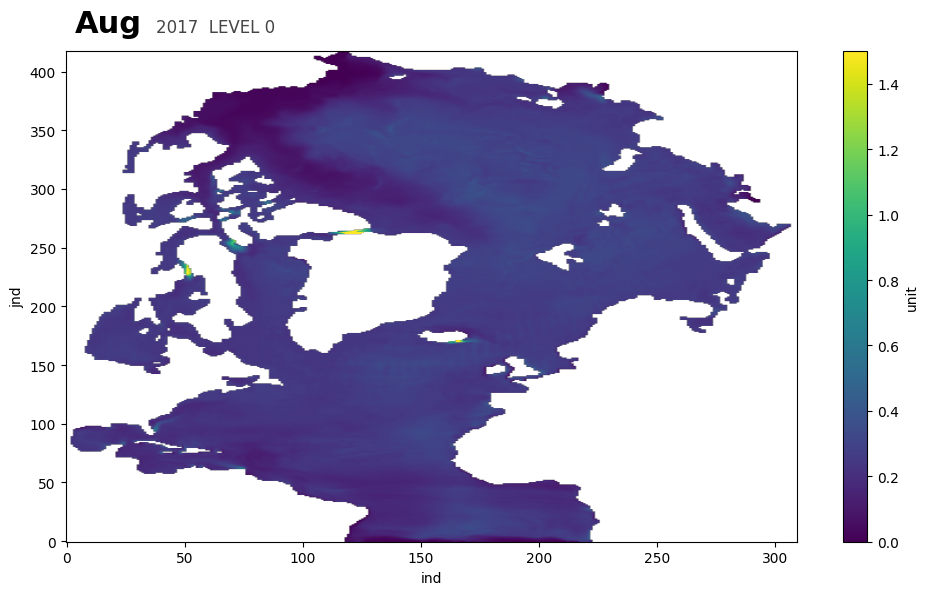

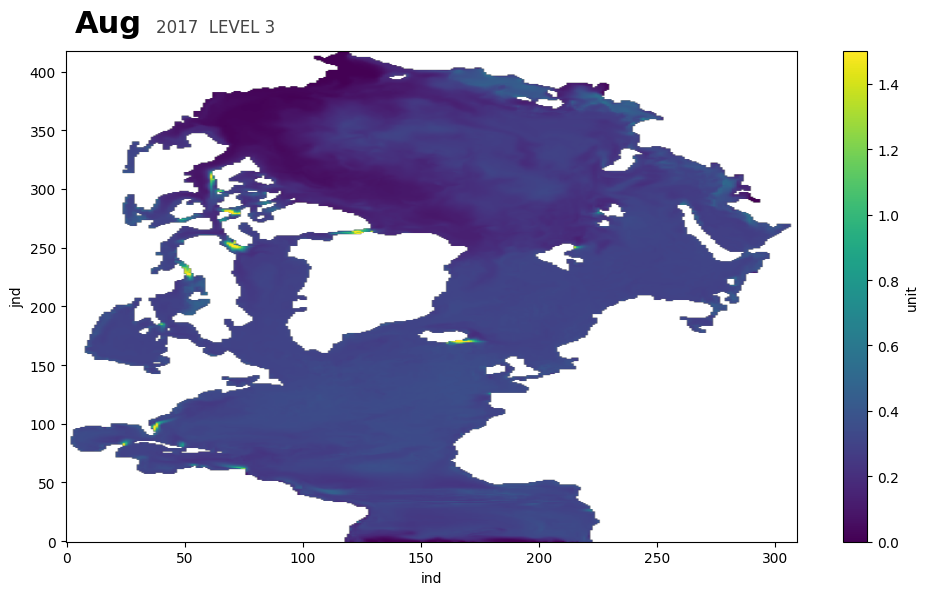

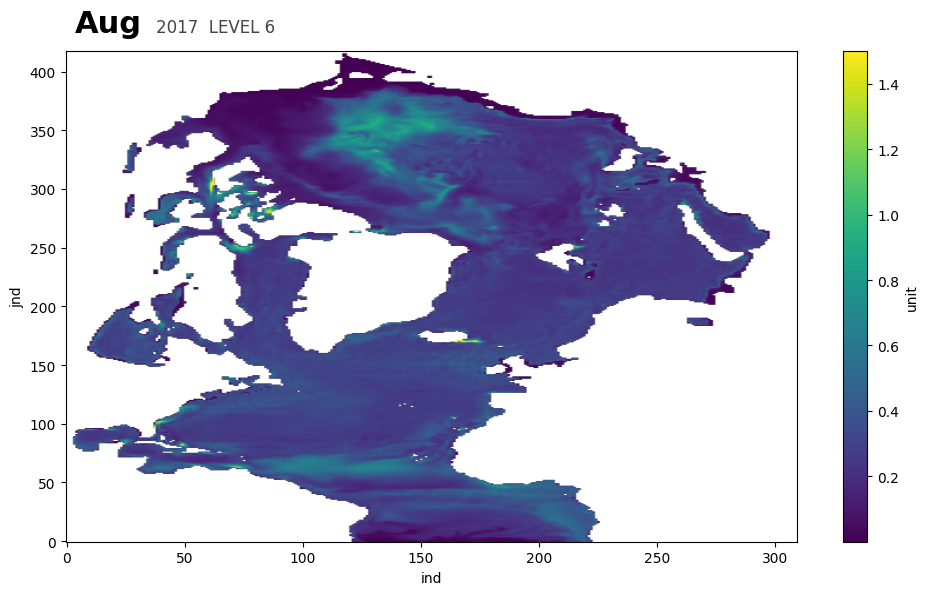

In [9]:
for depth in range(0,7,3):
    plot_snapshot(
        data_dir=DATA_DIR,
        year=SNAP_YEAR,
        month=SNAP_MONTH,
        var_name=VAR_NAME,
        depth_index=depth,
        out_path=OUT_DIR / f'{VAR_NAME}_{SNAP_YEAR:04d}_{SNAP_MONTH:02d}_{depth}.png',
        vmin=PLOT_VMIN,
        vmax=PLOT_VMAX,
        cmap=PLOT_CMAP,
    )


In [10]:
video_fps = VIDEO_FPS if VIDEO_FPS is not None else 1.0 / FRAME_DURATION_SEC

for depth in [0, 2, 5, 8]:
    make_video(
        data_dir=DATA_DIR,
        start_year=START_YEAR,
        start_month=START_MONTH,
        end_year=END_YEAR,
        end_month=END_MONTH,
        var_name=VAR_NAME,
        depth_index=depth,
        out_video=OUT_DIR / f'{VAR_NAME}_{depth}_{START_YEAR:04d}-{START_MONTH:02d}_{END_YEAR:04d}-{END_MONTH:02d}.mp4',
        fps=video_fps,
        vmin=PLOT_VMIN,
        vmax=PLOT_VMAX,
        cmap=PLOT_CMAP,
    )


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1391, 892) to (1392, 896) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Видео сохранено: pics\noadv\phyto_0_2011-01_2017-09.mp4
Кадры сохранены в: pics\noadv\phyto_0_2011-01_2017-09_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1391, 892) to (1392, 896) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Видео сохранено: pics\noadv\phyto_2_2011-01_2017-09.mp4
Кадры сохранены в: pics\noadv\phyto_2_2011-01_2017-09_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1391, 892) to (1392, 896) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Видео сохранено: pics\noadv\phyto_5_2011-01_2017-09.mp4
Кадры сохранены в: pics\noadv\phyto_5_2011-01_2017-09_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1391, 892) to (1392, 896) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Видео сохранено: pics\noadv\phyto_8_2011-01_2017-09.mp4
Кадры сохранены в: pics\noadv\phyto_8_2011-01_2017-09_frames
